In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/project/diabetes_012_health_indicators_BRFSS2015.csv")
X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_pred = rf.predict(X_test)



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


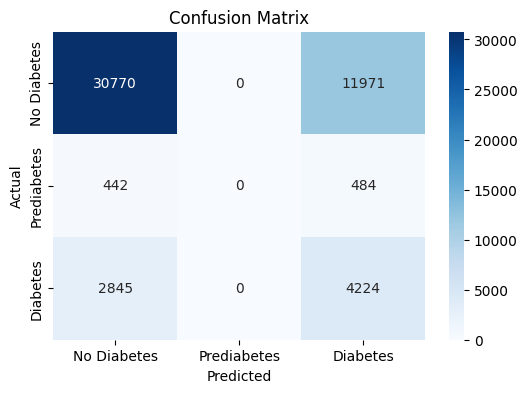


Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.90      0.72      0.80     42741
 Prediabetes       0.00      0.00      0.00       926
    Diabetes       0.25      0.60      0.36      7069

    accuracy                           0.69     50736
   macro avg       0.39      0.44      0.39     50736
weighted avg       0.80      0.69      0.72     50736



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


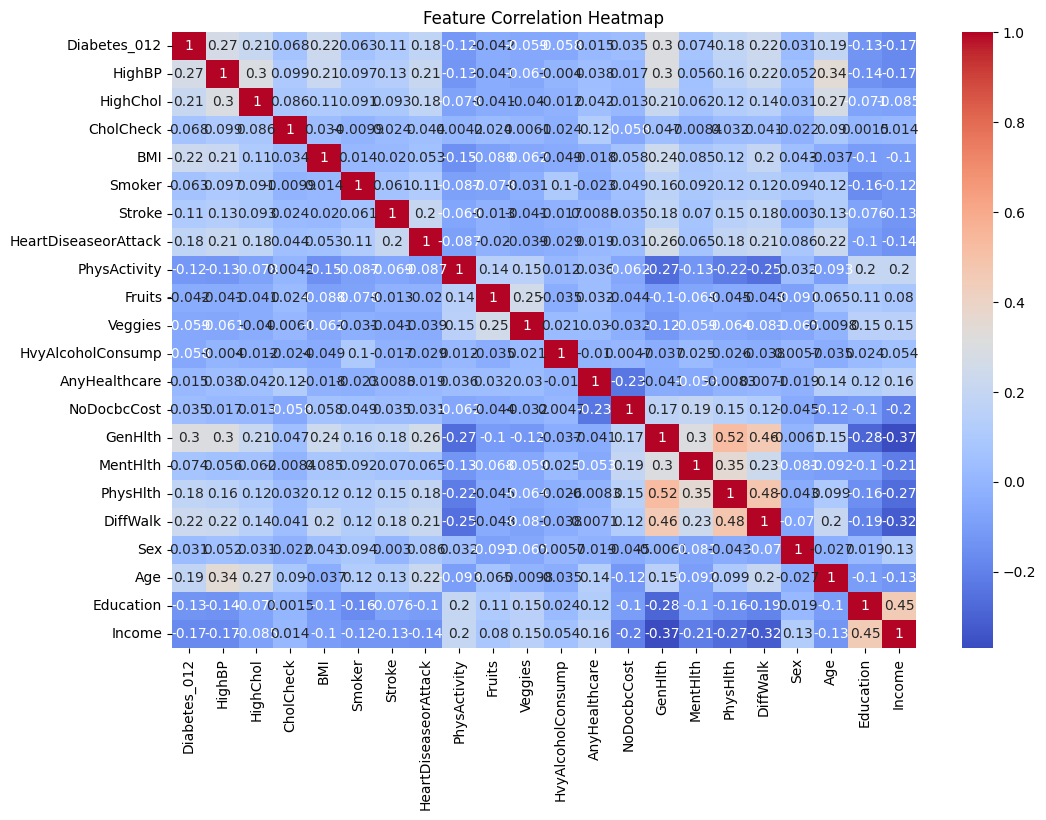

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Prediabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Prediabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Prediabetes', 'Diabetes']))

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Random Forest Accuracy: 0.8436


In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=500, multi_class="multinomial", class_weight="balanced")
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy: {lr_acc:.4f}")


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: {lr_acc:.4f}


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(y.unique()), activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, verbose=1, validation_split=0.2)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5074/5074 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8344 - loss: 0.4376 - val_accuracy: 0.8504 - val_loss: 0.3905
Epoch 2/10
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.8464 - loss: 0.4002 - val_accuracy: 0.8508 - val_loss: 0.3901
Epoch 3/10
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8483 - loss: 0.3966 - val_accuracy: 0.8507 - val_loss: 0.3905
Epoch 4/10
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - accuracy: 0.8469 - loss: 0.4006 - val_accuracy: 0.8503 - val_loss: 0.3908
Epoch 5/10
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8483 - loss: 0.3964 - val_accuracy: 0.8508 - val_loss: 0.3895
Epoch 6/10
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8497 - loss: 0.3939 - val_accuracy: 0.8504 - val_loss: 0.3900
Epoch 7/10
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.8513 - loss: 0.3911 - val_accuracy: 0.8507 - val_loss: 0.3896
Epoch 8/10
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.8485 - loss: 0.3939 - val

In [ ]:
dl_loss, dl_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Deep Learning Accuracy: {dl_acc:.4f}")

Deep Learning Accuracy: 0.8483
